In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
torch.manual_seed(42)
np.random.seed(42)

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

In [5]:
train_size = int(0.7 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

In [6]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [7]:
class DeepMLP(nn.Module):
    
    def __init__(self):
        super().__init__()
        
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
        
    def forward(self, x):
        return self.model(x)

In [8]:
def train_model(model, train_loader, val_loader, optimizer, criterion, epochs=10):

    train_losses = []
    val_losses = []
    train_acc = []
    val_acc = []

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    for epoch in range(epochs):

        model.train()
        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_losses.append(running_loss / len(train_loader))
        train_acc.append(correct / total)

        val_loss, val_accuracy = evaluate_model(model, val_loader, criterion)

        val_losses.append(val_loss)
        val_acc.append(val_accuracy)

        print(f"Epoch {epoch+1}/{epochs} | Train Acc {train_acc[-1]:.4f} | Val Acc {val_accuracy:.4f}")

    return train_losses, val_losses, train_acc, val_acc

In [9]:
def evaluate_model(model, loader, criterion):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.eval()

    loss_total = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss_total += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return loss_total / len(loader), correct / total

In [10]:
criterion = nn.CrossEntropyLoss()

In [11]:
model = DeepMLP()

optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

train_losses, val_losses, train_acc, val_acc = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs=15
)

Epoch 1/15 | Train Acc 0.7301 | Val Acc 0.8208
Epoch 2/15 | Train Acc 0.8398 | Val Acc 0.8503
Epoch 3/15 | Train Acc 0.8591 | Val Acc 0.8606
Epoch 4/15 | Train Acc 0.8679 | Val Acc 0.8451
Epoch 5/15 | Train Acc 0.8770 | Val Acc 0.8631
Epoch 6/15 | Train Acc 0.8810 | Val Acc 0.8709
Epoch 7/15 | Train Acc 0.8890 | Val Acc 0.8778
Epoch 8/15 | Train Acc 0.8946 | Val Acc 0.8765
Epoch 9/15 | Train Acc 0.8990 | Val Acc 0.8855
Epoch 10/15 | Train Acc 0.9015 | Val Acc 0.8857
Epoch 11/15 | Train Acc 0.9076 | Val Acc 0.8820
Epoch 12/15 | Train Acc 0.9111 | Val Acc 0.8901
Epoch 13/15 | Train Acc 0.9162 | Val Acc 0.8878
Epoch 14/15 | Train Acc 0.9195 | Val Acc 0.8837
Epoch 15/15 | Train Acc 0.9213 | Val Acc 0.8878


In [12]:
def plot_curves(train_loss, val_loss, train_acc, val_acc):

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(train_loss, label="Train Loss")
    plt.plot(val_loss, label="Val Loss")
    plt.legend()
    plt.title("Loss Curve")

    plt.subplot(1,2,2)
    plt.plot(train_acc, label="Train Acc")
    plt.plot(val_acc, label="Val Acc")
    plt.legend()
    plt.title("Accuracy Curve")

    plt.show()

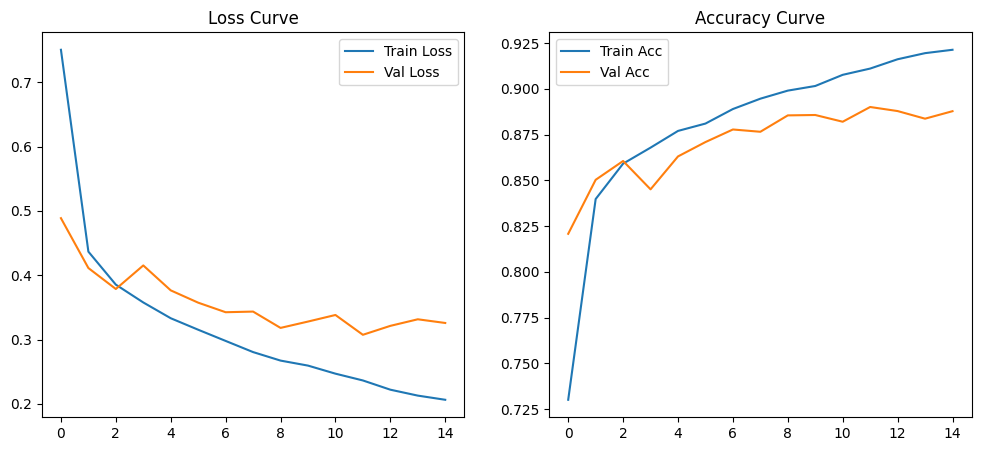

In [13]:
plot_curves(train_losses, val_losses, train_acc, val_acc)

In [14]:
def test_model(model, test_loader):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs,1)

            y_true.extend(labels.numpy())
            y_pred.extend(predicted.cpu().numpy())

    return y_true, y_pred

In [15]:
y_true, y_pred = test_model(model, test_loader)

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.76      0.81      1000
           1       0.98      0.97      0.97      1000
           2       0.85      0.75      0.80      1000
           3       0.87      0.88      0.87      1000
           4       0.76      0.87      0.81      1000
           5       0.95      0.96      0.96      1000
           6       0.66      0.73      0.70      1000
           7       0.94      0.94      0.94      1000
           8       0.97      0.97      0.97      1000
           9       0.96      0.95      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



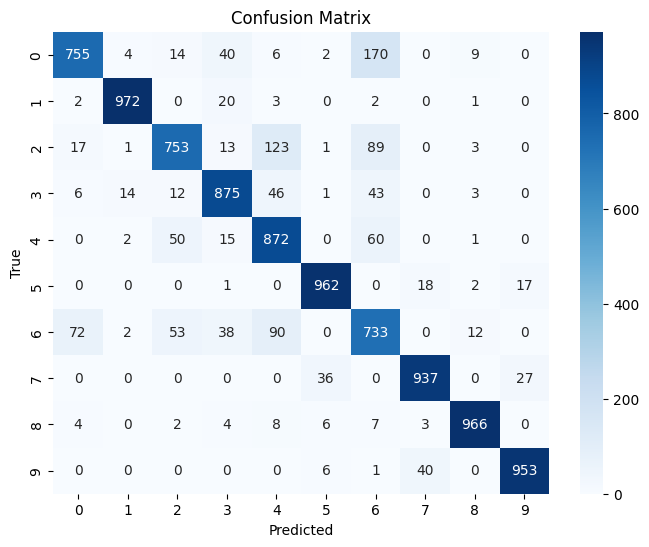

In [16]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

In [17]:
def show_misclassified(model, test_loader):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.eval()

    wrong_images = []
    wrong_preds = []
    wrong_labels = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            _, preds = torch.max(outputs,1)

            for i in range(len(preds)):

                if preds[i] != labels[i]:

                    wrong_images.append(images[i].cpu())
                    wrong_preds.append(preds[i].cpu())
                    wrong_labels.append(labels[i])

            if len(wrong_images) >= 15:
                break

    plt.figure(figsize=(10,6))

    for i in range(15):

        plt.subplot(3,5,i+1)
        plt.imshow(wrong_images[i].squeeze(), cmap='gray')
        plt.title(f"P:{wrong_preds[i]} T:{wrong_labels[i]}")
        plt.axis("off")

    plt.show()

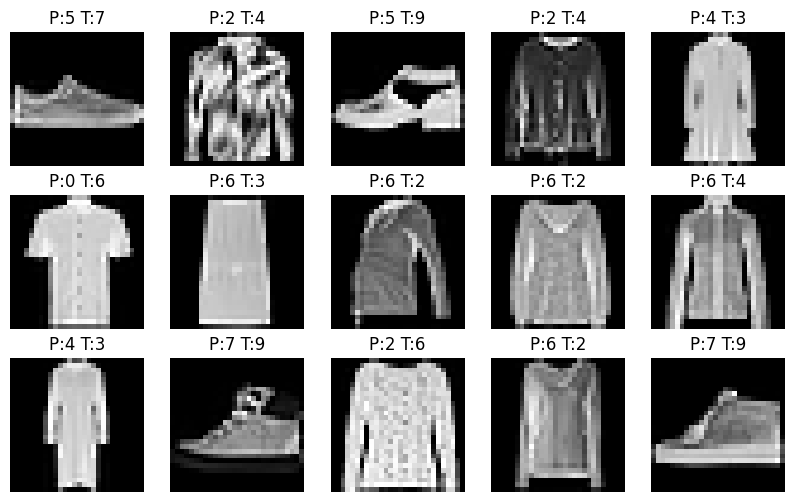

In [18]:
show_misclassified(model, test_loader)